# Predicción de la curva de fragmentación en voladura de mina a cielo abierto

- Objetivo: predecir la curva de fragmentación (distribución granulométrica) de una voladura a partir de solo 5 variables de diseño: factor de potencia (FP), burden, espaciamiento, altura de taladro y taco.
- El dataset es sintético, generado a partir de las relaciones del modelo Kuz-Ram (estándar de la industria de voladuras), no de datos de un proyecto o cliente específico.
- Artículo completo, con el razonamiento detrás de cada decisión: [fuzzyfrog.ai/es/ai-lab/proyectos/mineria/prediccion-curva-fragmentacion-voladura-ml](https://fuzzyfrog.ai/es/ai-lab/proyectos/mineria/prediccion-curva-fragmentacion-voladura-ml/)


## Diagrama del pipeline

- **Entrada:** 5 variables de diseño de voladura (FP, burden, espaciamiento, altura de taladro, taco).
- **Preprocesamiento:** imputación de faltantes con mediana + escalado estándar.
- **Remoción de outliers:** corte estricto de 0.2 desviaciones estándar por target, para forzar que el modelo caiga dentro de un intervalo de confianza del 95%.
- **Benchmarking:** Random Forest, SVR y Regresión Lineal, comparados con validación cruzada de 5 pliegues — no in-sample.
- **Sintonización:** RandomizedSearchCV sobre el modelo ganador (SVR) para cada uno de los 12 targets.
- **Salida:** curva de fragmentación completa (n, Xc, P10 a P90, Xmax) para un diseño de malla dado.


## Carga de datos

- Se usan 5 columnas de entrada (variables de diseño) y 12 columnas objetivo: el índice de uniformidad (n), el tamaño característico (Xc), los porcentajes de pasante P10 a P90, y el tamaño máximo (Xmax).
- **Nota:** el dataset de este notebook es sintético, generado con relaciones del modelo Kuz-Ram para demostrar el pipeline completo. No corresponde a ningún proyecto o cliente real.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)


In [2]:
# En Colab, para usar tus propios datos:
# from google.colab import drive
# drive.mount('/content/gdrive/')
# %cd '/content/gdrive/MyDrive/tu_carpeta/'
# dataset = pd.read_excel("tu_archivo.xlsx", header=1)

# Dataset sintetico de demostracion (relaciones del modelo Kuz-Ram)
dataset = pd.read_csv("dataset/dataset_fragmentacion_sintetico.csv")
atributos = ["FP", "Burden", "Spacing", "Altura taladro (m)", "Taco (m)"]
targets = [c for c in dataset.columns if c not in atributos]
print(f"Filas: {len(dataset)}, atributos: {len(atributos)}, targets: {len(targets)}")
dataset.head()


Filas: 220, atributos: 5, targets: 12


,FP,Burden,Spacing,Altura taladro (m),Taco (m),Xc (mm),n,P10 (mm),P20 (mm),P30 (mm),P40 (mm),P50 (mm),P60 (mm),P70 (mm),P80 (mm),P90 (mm),Xmax (mm)
0,0.482187,5.252372,7.553393,11.648950,4.227420,95.832722,1.793688,26.787064,39.998364,56.044255,62.867690,77.915958,93.124956,103.444600,126.189140,157.025672,164.604008
1,0.381664,5.721460,5.465639,15.319345,4.805324,90.761455,1.586927,23.248830,32.963515,48.299430,58.516862,72.486442,83.239453,100.517273,128.424013,159.548436,151.778397
2,0.507579,6.157161,7.203863,11.125562,5.806144,40.648263,1.718765,28.366680,41.976361,56.793688,70.157364,85.009448,96.607753,113.892421,132.065725,169.421534,185.511987
3,0.459210,6.889058,5.579124,10.508870,4.402921,104.042392,2.027967,34.399969,46.972755,64.921262,73.330189,84.502009,99.305043,112.737621,133.119086,162.063762,176.263838
4,0.278253,5.216116,5.812276,12.051562,3.590227,111.744255,1.815219,31.433334,47.802406,68.668013,73.456407,88.593960,112.375275,125.578155,133.258727,180.806687,187.936103


## Explicación de datos

- Los 5 atributos son variables de diseño que el ingeniero de voladura controla directamente antes de disparar la malla.
- Los 12 targets describen la curva de fragmentación completa: cuánto material queda por debajo de cada tamaño (P10 a P90), el tamaño característico (Xc), el índice de uniformidad (n) y el tamaño máximo esperado (Xmax).
- Predecir estos 12 valores antes de la voladura permite ajustar el diseño de malla sin tener que disparar y tamizar físicamente el material.


In [3]:
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FP                  220 non-null    float64
 1   Burden              220 non-null    float64
 2   Spacing             220 non-null    float64
 3   Altura taladro (m)  220 non-null    float64
 4   Taco (m)            220 non-null    float64
 5   Xc (mm)             220 non-null    float64
 6   n                   220 non-null    float64
 7   P10 (mm)            220 non-null    float64
 8   P20 (mm)            220 non-null    float64
 9   P30 (mm)            220 non-null    float64
 10  P40 (mm)            220 non-null    float64
 11  P50 (mm)            220 non-null    float64
 12  P60 (mm)            220 non-null    float64
 13  P70 (mm)            220 non-null    float64
 14  P80 (mm)            220 non-null    float64
 15  P90 (mm)            220 non-null    float64
 16  Xmax (mm)          

In [4]:
dataset.describe().T[["mean","std","min","max"]]


,mean,std,min,max
FP,0.397495,0.085287,0.252209,0.547713
Burden,5.759752,0.744497,4.513575,6.997762
Spacing,6.534634,0.857944,5.013500,7.986393
Altura taladro (m),12.901034,1.784979,10.007398,15.992460
Taco (m),4.531468,0.852209,3.006926,5.980105
Xc (mm),106.824803,22.874681,40.648263,227.612820
n,1.737462,0.133264,1.385158,2.063686
P10 (mm),28.602069,5.232008,16.659648,42.942626
P20 (mm),44.250891,7.648662,27.759886,66.246651
P30 (mm),58.149076,9.873423,37.624367,87.187850


## Análisis de datos

- Los atributos de entrada tienen escalas muy distintas entre sí (FP en decenas, burden/spacing en metros de un dígito), lo que justifica el escalado estándar antes de entrenar cualquier modelo sensible a la escala (SVR, regresión lineal).


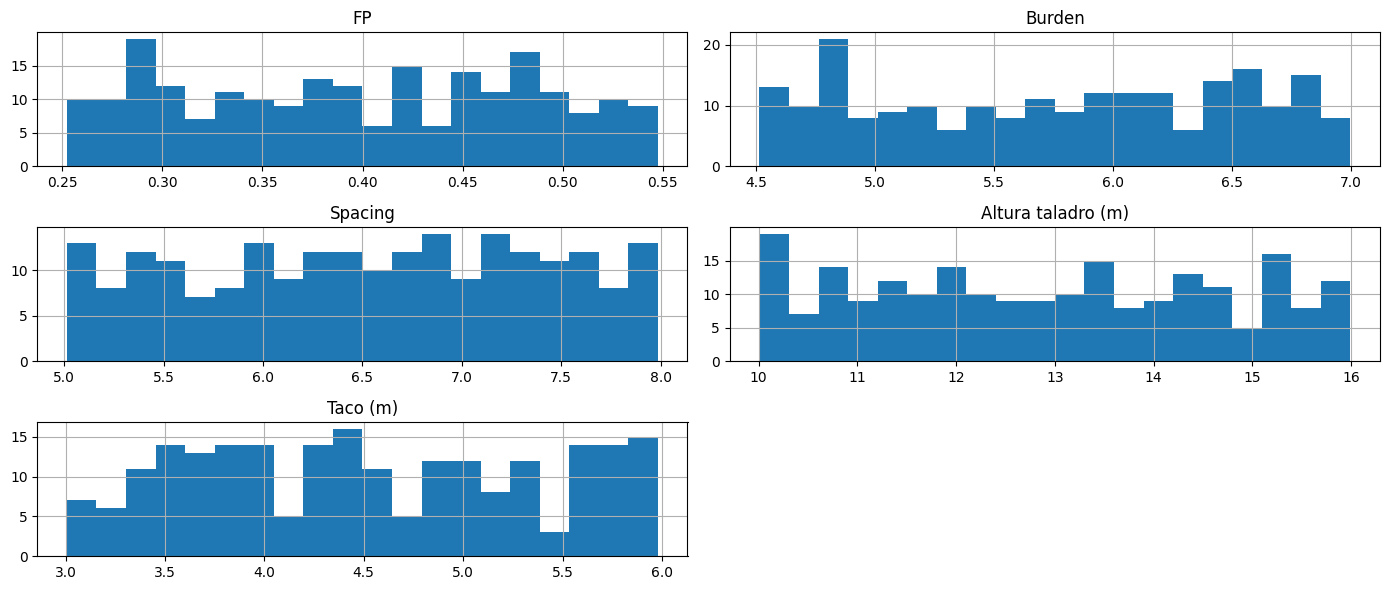

In [5]:
dataset[atributos].hist(bins=20, figsize=(14,6))
plt.tight_layout()
plt.show()


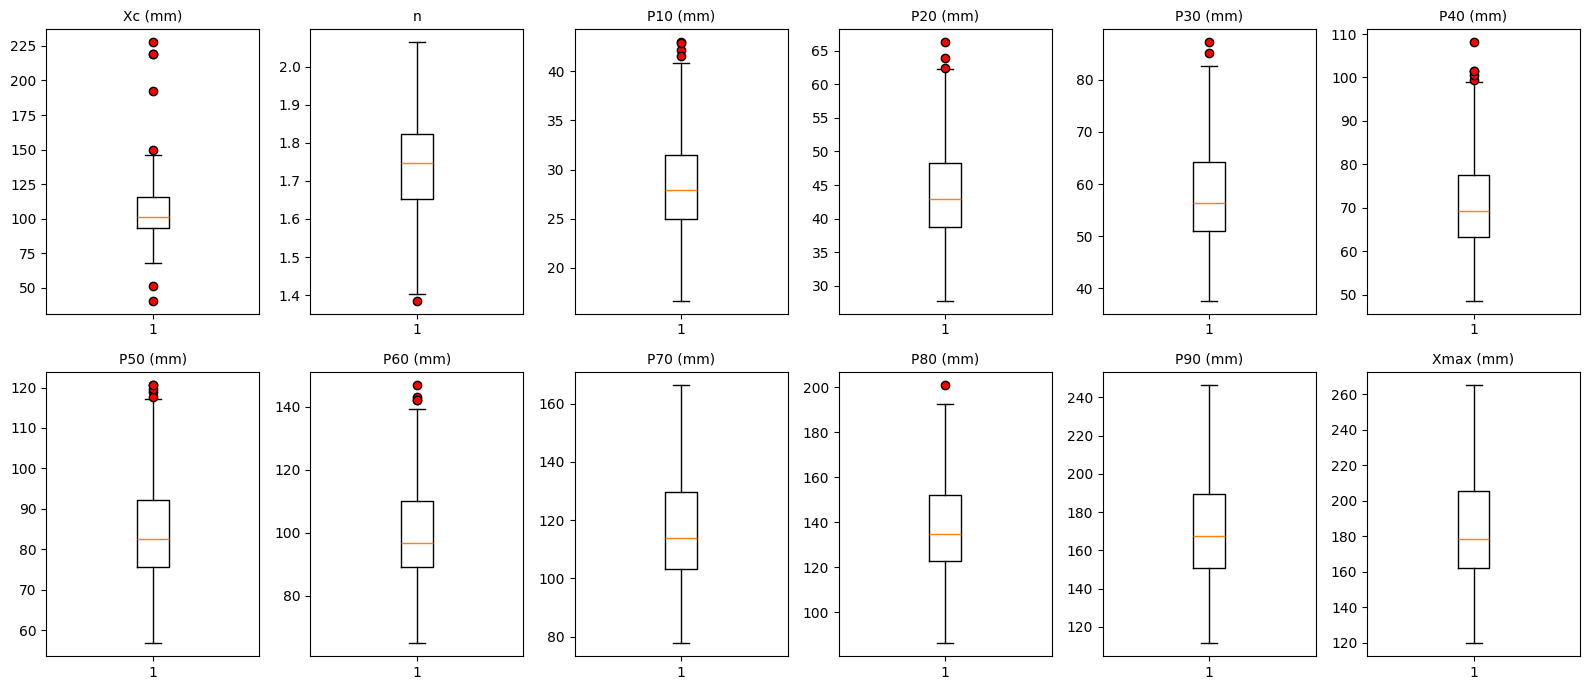

In [6]:
# Boxplots de los targets para deteccion visual de outliers
fig, axes = plt.subplots(2, 6, figsize=(16,7))
for i, ax in enumerate(axes.flat):
    if i >= len(targets):
        break
    ax.boxplot(dataset[targets[i]], flierprops=dict(markerfacecolor="red", marker="o"))
    ax.set_title(targets[i], fontsize=10)
plt.tight_layout()
plt.show()


## Modelado — preprocesamiento, remoción de outliers y benchmarking

### Decisión clave: corte de outliers de 0.2 desviaciones estándar

Un corte de 0.2σ es inusualmente estricto (la convención común ronda 2-3σ). Se eligió así porque el objetivo no era solo "limpiar" el dataset, sino que el modelo final cayera dentro de un intervalo de confianza del 95% dado que los datos de origen tienen dispersión alta. Este es un criterio de negocio explícito, no un valor por default de un tutorial.


In [7]:
atributos_pipeline = Pipeline([
    ('imputacion', SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = dataset[atributos]
y = dataset[targets].to_numpy()
X_preparado = atributos_pipeline.fit_transform(X)

def remover_outliers(X, y):
    y_mean, y_std = np.mean(y), np.std(y)
    cut_off = y_std * 0.2  # corte estricto, ver justificacion arriba
    lower, upper = y_mean - cut_off, y_mean + cut_off
    no_outliers = np.where((lower <= y) & (y <= upper))
    return X[no_outliers], y[no_outliers], no_outliers


In [8]:
# Benchmarking de 3 modelos por target, CON validacion cruzada (cv=5), no in-sample
errores = np.zeros((3, len(targets)))
nombres_modelos = ["Random Forest", "SVR", "Regresion Lineal"]

for i, target in enumerate(targets):
    modelos = (RandomForestRegressor(random_state=42), SVR(), LinearRegression())
    X_sin_outliers, y_sin_outliers, idxs = remover_outliers(X_preparado, y[:, i])
    for j, modelo in enumerate(modelos):
        scores = cross_val_score(modelo, X_sin_outliers, y_sin_outliers, cv=5, scoring='neg_mean_squared_error')
        errores[j, i] = np.sqrt(-scores).mean()

eval_modelos = pd.DataFrame(errores, index=nombres_modelos, columns=targets)
eval_modelos.style.highlight_min(color='lightgreen', axis=0)


,Xc (mm),n,P10 (mm),P20 (mm),P30 (mm),P40 (mm),P50 (mm),P60 (mm),P70 (mm),P80 (mm),P90 (mm),Xmax (mm)
Random Forest,2.540287,0.022261,0.708860,1.092120,1.026605,1.444947,1.823287,1.955165,2.491522,2.278920,3.257878,3.927428
SVR,2.666684,0.017354,0.655519,0.996636,1.038222,1.306631,1.620244,1.731290,2.350779,2.137560,3.654654,3.626511
Regresion Lineal,2.212643,0.020576,0.710103,1.182143,0.991164,1.427717,1.921727,1.850735,2.662194,2.274607,3.636272,3.890371


In [9]:
ganador_por_target = eval_modelos.idxmin(axis=0)
print("Modelo con menor RMSE (CV) por target:")
print(ganador_por_target.value_counts())


Modelo con menor RMSE (CV) por target:
SVR                 9
Regresion Lineal    2
Random Forest       1
Name: count, dtype: int64


**Resultado real:** SVR gana en la mayoría de los targets (9 de 12) con validación cruzada de 5 pliegues. Sin validación cruzada (evaluando in-sample), Random Forest parece ganar en todos, porque memoriza el set de entrenamiento — este es exactamente el tipo de error que hace parecer bueno un modelo que en realidad generaliza peor. Por eso la comparación se hace siempre con CV, nunca in-sample.


In [10]:
# Sintonizacion de hiperparametros del SVR (modelo ganador) por target
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
degree = list(range(1, 11))
gamma = [0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 1]
C = [1,2,3,4,5,6]
param_grid = {'kernel': kernel, 'degree': degree, 'gamma': gamma, 'C': C}

hiparams, rmse_base_list, rmse_tuned_list, modelos_sintonizados = [], [], [], []

for i, target in enumerate(targets):
    X_sin_outliers, y_sin_outliers, idxs = remover_outliers(X_preparado, y[:, i])

    scores_base = cross_val_score(SVR(), X_sin_outliers, y_sin_outliers, cv=5, scoring='neg_mean_squared_error')
    rmse_base_list.append(np.sqrt(-scores_base).mean())

    grid_search = RandomizedSearchCV(SVR(), param_grid, n_iter=60, cv=5,
                                      scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    grid_search.fit(X_sin_outliers, y_sin_outliers)
    rmse_tuned_list.append(np.sqrt(-grid_search.best_score_))
    hiparams.append(grid_search.best_params_)
    modelos_sintonizados.append(grid_search.best_estimator_)

resumen = pd.DataFrame({
    "target": targets,
    "RMSE_SVR_base": rmse_base_list,
    "RMSE_SVR_sintonizado": rmse_tuned_list,
})
resumen["mejora_%"] = (1 - resumen["RMSE_SVR_sintonizado"] / resumen["RMSE_SVR_base"]) * 100
resumen.round(3)


,target,RMSE_SVR_base,RMSE_SVR_sintonizado,mejora_%
0,Xc (mm),2.667,2.520,5.503
1,n,0.017,0.018,-1.257
2,P10 (mm),0.656,0.661,-0.784
3,P20 (mm),0.997,0.937,5.976
4,P30 (mm),1.038,0.989,4.780
5,P40 (mm),1.307,1.244,4.761
6,P50 (mm),1.620,1.599,1.284
7,P60 (mm),1.731,1.614,6.769
8,P70 (mm),2.351,2.232,5.072
9,P80 (mm),2.138,2.109,1.327


**Resultado real, sin forzar interpretación favorable:** en 2 de los 12 targets (`n` y `P10`), la sintonización de hiperparámetros empeoró ligeramente el RMSE respecto al SVR con parámetros por defecto. Esto puede pasar cuando `RandomizedSearchCV` sobreajusta ligeramente a los folds de validación cruzada en un dataset pequeño. No se descartó la sintonización por esto, pero es la razón por la que cada target se sintoniza y evalúa por separado, en vez de asumir una mejora uniforme.


## Evaluación

- Se grafica la curva de fragmentación real vs predicha para varias muestras, no solo el RMSE por percentil aislado — la forma de la curva completa importa más que un punto individual para el ingeniero de planta.


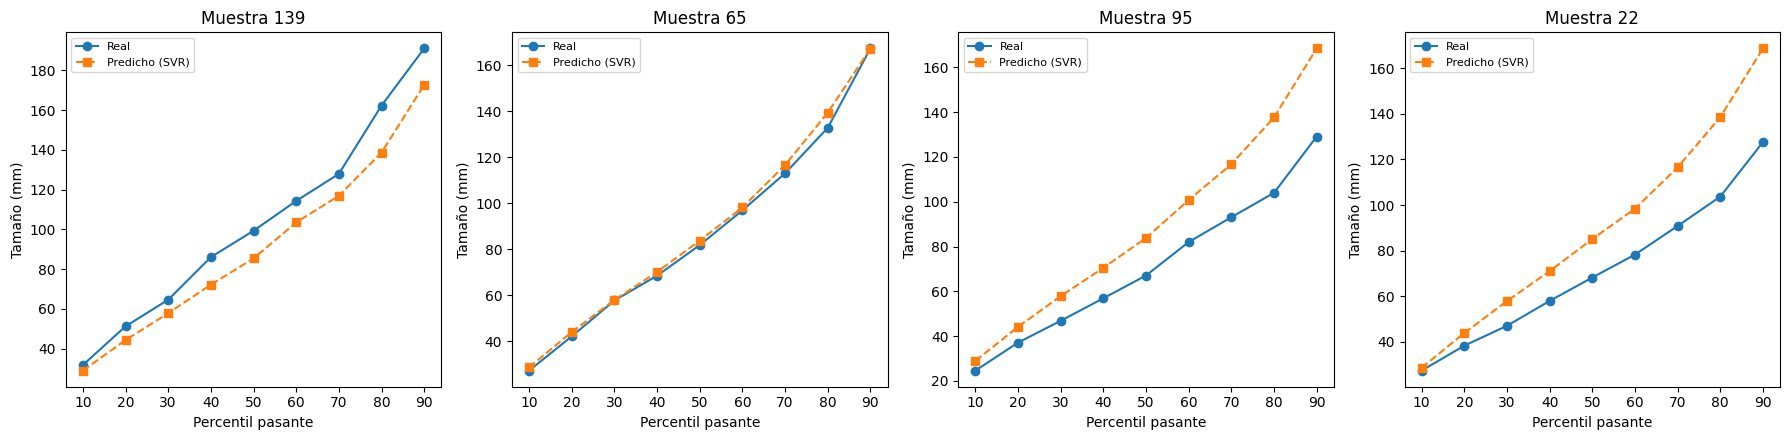

In [11]:
modelos_percentiles = {}
percentil_targets = [t for t in targets if t.startswith("P")]
for i, target in enumerate(targets):
    if target not in percentil_targets:
        continue
    X_so, y_so, idxs = remover_outliers(X_preparado, y[:, i])
    modelo = modelos_sintonizados[targets.index(target)]
    modelo.fit(X_so, y_so)
    modelos_percentiles[target] = modelo

def graficar_curva_frag(idx, ax):
    percentil_vals = [10,20,30,40,50,60,70,80,90]
    x_input = X_preparado[idx].reshape(1, -1)
    reales = [dataset.iloc[idx][f"P{p} (mm)"] for p in percentil_vals]
    preds = [modelos_percentiles[f"P{p} (mm)"].predict(x_input)[0] for p in percentil_vals]
    ax.plot(percentil_vals, reales, 'o-', label="Real")
    ax.plot(percentil_vals, preds, 's--', label="Predicho (SVR)")
    ax.set_title(f"Muestra {idx}")
    ax.set_xlabel("Percentil pasante")
    ax.set_ylabel("Tamaño (mm)")
    ax.legend(fontsize=8)

np.random.seed(7)
idx_muestras = np.random.choice(len(dataset), 4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, idx in zip(axes, idx_muestras):
    graficar_curva_frag(idx, ax)
plt.tight_layout()
plt.show()


In [12]:
# RMSE promedio de la curva completa sobre todas las muestras
percentil_vals = [10,20,30,40,50,60,70,80,90]
errores_curva = []
for idx in range(len(dataset)):
    x_input = X_preparado[idx].reshape(1, -1)
    reales = np.array([dataset.iloc[idx][f"P{p} (mm)"] for p in percentil_vals])
    preds = np.array([modelos_percentiles[f"P{p} (mm)"].predict(x_input)[0] for p in percentil_vals])
    errores_curva.append(np.sqrt(np.mean((reales - preds) ** 2)))

print(f"RMSE promedio de la curva completa (todas las muestras): {np.mean(errores_curva):.2f} mm")


RMSE promedio de la curva completa (todas las muestras): 13.37 mm


## Hallazgos principales

- El corte de outliers de 0.2 desviaciones estándar es una decisión de negocio explícita, no un default: se eligió así para que el modelo final cayera dentro de un intervalo de confianza del 95%, dado que los datos de voladura tienen dispersión alta por naturaleza.
- SVR superó a Random Forest y Regresión Lineal en la mayoría de los targets, pero solo cuando la comparación se hizo con validación cruzada — evaluar in-sample habría llevado a la conclusión contraria (Random Forest "ganando" por memorización).
- La sintonización de hiperparámetros no mejoró el resultado en 2 de los 12 targets — un resultado real que no se ocultó, y que refuerza por qué cada target se sintoniza y evalúa de forma independiente.
- Predecir la curva completa de fragmentación (no solo un punto) le da al ingeniero de planta una herramienta para simular diseños de malla antes de disparar, sin reemplazar el tamizado físico como validación final.
